# Code

In [ ]:
!pip install openai

In [ ]:
from openai import OpenAI

In [ ]:
import torch
import pandas as pd
from torch import nn

In [ ]:
client = OpenAI(api_key='ENTER_KEY')

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [ ]:
def get_embedding_safe(text, model="text-embedding-ada-002"):
    """Generate embeddings with error handling."""
    try:
        text = text.replace("\n", " ")
        response = client.embeddings.create(input=[text], model=model)
        embedding = response.data[0].embedding

        if not embedding:
            raise ValueError(f"No embedding generated for: {text}")

        print(f"Embedding for '{text[:20]}...': {embedding[:5]}...")
        return embedding
    except Exception as e:
        print(f"Error generating embedding for '{text}': {e}")
        return None

In [ ]:
df = pd.read_excel("/content/Augmented_Customer_Needs_f.xlsx")

In [ ]:
df

,Customer Need,Evidence Gap,Unique Customer need
0,Price - effectiveness vs. biologics (Cost of t...,Cost-effectiveness,Need for cost-effectiveness data for the drug
1,Cost - effectiveness vs. biologics (Cost of th...,Cost-effectiveness,Need for cost-effectiveness data for the drug
2,Cost - effectiveness vs. biologics (Monetary v...,Cost-effectiveness,Need for cost-effectiveness data for the drug
3,Cost - effectiveness vs. biologics (Cost of th...,Cost-effectiveness,Need for cost-effectiveness data for the drug
4,Price - effectiveness vs. biologics (Cost of t...,Cost-effectiveness,Need for cost-effectiveness data for the drug
...,...,...,...
154,Need for quality of life (QoL) data for the dr...,Value Evidence to Payers,Need for data on value evidence
155,Stakeholders are requesting for wellness econo...,Value Evidence to Payers,Need for data on value evidence
156,Stakeholders are quest for health economics da...,Value Evidence to Payers,Need for data on value evidence
157,Stakeholder are requesting for health economic...,Value Evidence to Payers,Need for data on value evidence


In [ ]:
customer_need = df['Customer Need'].to_list()
evidence_gap = df['Evidence Gap'].to_list()

In [ ]:
def train_model(model, x_train, y_train, batch_size=32, epochs=10):
    """
    Trains the ANN model.

    Args:
        model: Keras model.
        x_train: Training input data (numpy array).
        y_train: Training labels (numpy array).
        batch_size: Batch size for training.
        epochs: Number of training epochs.

    Returns:
        History object containing training loss/metrics.
    """
    history = model.fit(x_train, y_train, batch_size=batch_size, epochs=epochs, validation_split=0.2)
    return history

In [ ]:
customer_needs_vector = []
for need in customer_need:
  customer_needs_vector.append(get_embedding_safe(need))

Embedding for 'Price - effectivenes...': [-0.010642538778483868, 0.004555858206003904, 0.01021657045930624, -0.00975066889077425, 0.014536149799823761]...
Embedding for 'Cost - effectiveness...': [-0.0048817661590874195, 0.003370586782693863, 0.017358850687742233, -0.005463241599500179, 0.01196459773927927]...
Embedding for 'Cost - effectiveness...': [-0.0053191171027719975, 0.003460551146417856, 0.01967119425535202, -0.009894807823002338, 0.011743505485355854]...
Embedding for 'Cost - effectiveness...': [-0.00699148653075099, 0.003149168100208044, 0.02180757187306881, 0.0015129336388781667, 0.013223173096776009]...
Embedding for 'Price - effectivenes...': [-0.00832277536392212, 0.008757350035011768, 0.009461889043450356, -0.006689825560897589, 0.016566535457968712]...
Embedding for 'Cost - effectiveness...': [-0.0019035683944821358, 0.0012554209679365158, 0.017831148579716682, -0.005618947092443705, 0.016816800460219383]...
Embedding for 'Need data on cost of...': [-0.0055949846282601

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# Example embeddings (1000 samples, 1536 features)
embeddings = np.array(customer_needs_vector)

# Example labels (words corresponding to 8 classes)
labels = np.array(evidence_gap)

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)  # Output a dense array
labels_one_hot = encoder.fit_transform(labels.reshape(-1, 1))  # Transform labels

# Train-test split (80% train, 20% test)
x_train, x_test, y_train, y_test = train_test_split(embeddings, labels_one_hot, test_size=0.2, random_state=42)
# Print Example
print(f"Original Labels: {labels[:5]}")
print(f"One-Hot Encoded Labels:\n{y_train[:5]}")
print(f"Label Categories: {encoder.categories_}")  # Show class mappings

Original Labels: ['Cost-effectiveness' 'Cost-effectiveness' 'Cost-effectiveness'
 'Cost-effectiveness' 'Cost-effectiveness']
One-Hot Encoded Labels:
[[0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]]
Label Categories: [array(['Cost-effectiveness',
       'Differentiate vs. standard of care (SOC) MoA',
       'Dose optimization / Treatment (Tx) regimen',
       'Life-cycle management (LCM) Opportunity',
       'Risk Factors for adverse events (AEs)',
       'Safety in special populations', 'Tx adherence',
       'Value Evidence to Payers'], dtype='<U44')]


In [ ]:
def create_ann(input_size=1536, hidden_size=512, output_size=8):
    model = keras.Sequential([
        layers.Dense(hidden_size, activation='relu', input_shape=(input_size,)),  # Hidden layer
        layers.Dense(hidden_size, activation='relu', input_shape=(hidden_size,)),  # Hidden layer
        layers.Dense(output_size, activation='softmax')  # Output layer (softmax for classification)
    ])
    return model

# 5️⃣ Compile & Train Model
model = create_ann()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(x_train, y_train, validation_split=0.2, epochs=20, batch_size=8)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.2016 - loss: 2.0030 - val_accuracy: 0.5000 - val_loss: 1.7444
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5583 - loss: 1.5246 - val_accuracy: 0.7308 - val_loss: 1.2955
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9109 - loss: 0.8670 - val_accuracy: 0.9231 - val_loss: 0.8052
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9903 - loss: 0.3661 - val_accuracy: 0.9231 - val_loss: 0.4299
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9846 - loss: 0.1124 - val_accuracy: 0.9615 - val_loss: 0.2050
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0535 - val_accuracy: 1.0000 - val_loss: 0.1206
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0356 - val_accuracy: 1.0000 - val_loss: 0.0747
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 1.0000 - loss: 0.0170 - val_accuracy: 1.0000 - val_loss: 0.0539


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0066


In [ ]:
df_new_unseen = pd.read_excel("/content/Filtered_Customer_Needs (1).xlsx")

In [ ]:
customer_needs_unseen_text = df_new_unseen['Customer Need'].to_list()
evidence_gap_unseen = df_new_unseen['Evidence Gap'].to_list()

In [ ]:
customer_needs_unseen_vector = []
for need in customer_needs_unseen_text:
  customer_needs_unseen_vector.append(get_embedding_safe(need))

Embedding for 'Cost-effectiveness v...': [-0.001000966876745224, 0.00023132101341616362, 0.019452936947345734, -0.007148368284106255, 0.010872290469706059]...
Embedding for 'Need data on cost of...': [-0.0024180978070944548, 0.01536403875797987, 0.01556852925568819, -0.04730542376637459, -0.0128010930493474]...
Embedding for 'Data need for drug's...': [-0.005149318836629391, 0.007720595225691795, 0.01016330812126398, -0.027485590428113937, -0.02278962731361389]...
Embedding for 'Need for data based ...': [0.004666980821639299, 0.004606151022017002, 0.005065752658993006, -0.023899266496300697, -0.009955774992704391]...
Embedding for 'More data needed to ...': [-0.007888320833444595, 0.01401040144264698, 0.004213080741465092, -0.03596224635839462, -0.0036221204791218042]...
Embedding for 'Need data on drug to...': [-0.007051028311252594, 0.0043299272656440735, 0.01159281749278307, -0.028283562511205673, -0.005260133184492588]...
Embedding for 'Need data on drug's ...': [-0.01800468936562

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# Example embeddings (1000 samples, 1536 features)
embeddings = np.array(customer_needs_unseen_vector)

# Example labels (words corresponding to 8 classes)
labels = np.array(evidence_gap_unseen)

# Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)  # Output a dense array
labels_one_hot = encoder.fit_transform(labels.reshape(-1, 1))  # Transform labels

In [ ]:
test_loss, test_acc = model.evaluate(embeddings, labels_one_hot)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 1.0000 - loss: 0.0024


In [ ]:
def plot_training_history(history):
    """
    Plots training & validation loss and accuracy from a Keras history object.

    Args:
        history: Keras training history object.
    """
    # Extract data from history object
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    accuracy = history.history['accuracy']
    val_accuracy = history.history['val_accuracy']
    epochs = range(1, len(loss) + 1)  # Get number of epochs
    # Plot Loss
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, loss, label="Training Loss")
    plt.plot(epochs, val_loss, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training & Validation Loss Over Epochs")
    plt.legend()
    plt.show()
    # Plot Accuracy
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, accuracy, label="Training Accuracy")
    plt.plot(epochs, val_accuracy, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.title("Training & Validation Accuracy Over Epochs")
    plt.legend()
    plt.show()


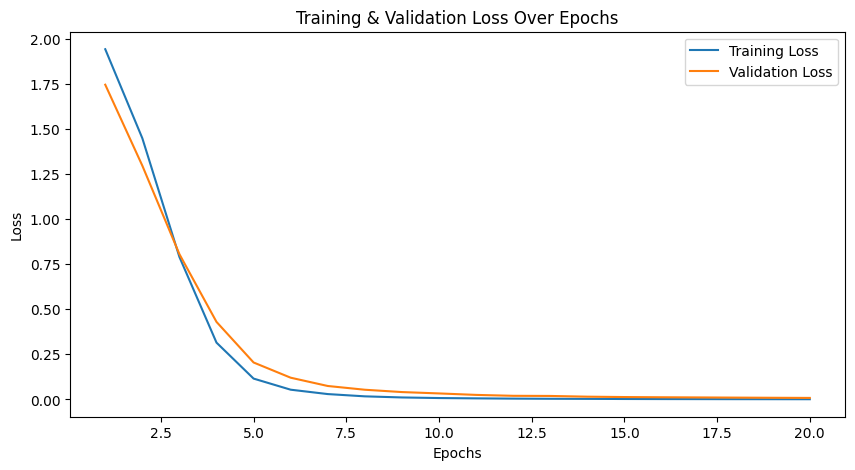

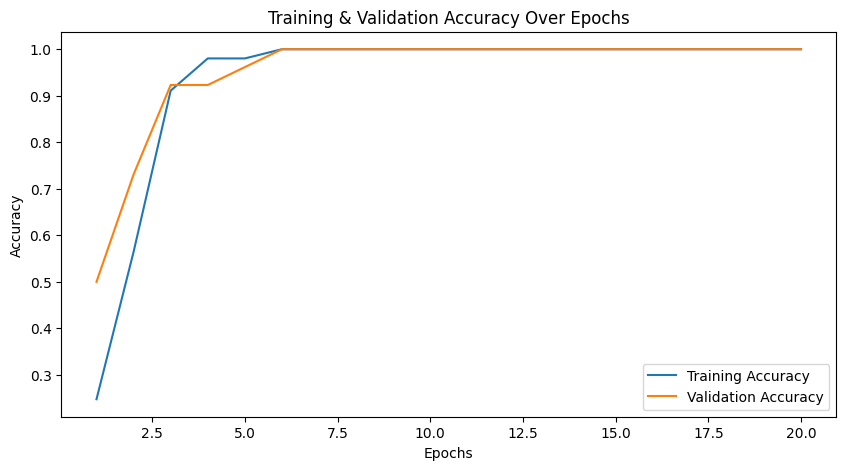

In [ ]:
plot_training_history(history)